# NEM EU ENTENDI O QUE TAVA ACONTECENDO AQUI, APENAS TESTES

In [1]:
import pandas as pd

# Carrega o dataset já agrupado e com coluna 'Dia da Semana'
df = pd.read_excel("insumos_vendidos_por_dia.xlsx")
df.head()

,Data,ARR,BAC,BERIN,CARN,COST,COST S,FEIJ,FEIJOA,FRAL,FRANG,MAMI,MASS,MOLH,MOLH B,PEIX,POL,TUTU
0,2024-03-12,7740,0,0,0,0,0,5160,0,0,1550,1950,1000,800,0,2210,0,0
1,2024-03-13,12960,0,0,0,1560,0,2520,12750,0,1170,0,1000,800,0,0,0,0
2,2024-03-14,6480,0,0,0,0,0,1680,0,1430,390,0,1400,160,960,0,650,3960
3,2024-03-15,11520,1040,0,6110,0,910,7680,0,0,260,0,2800,0,2240,0,0,0
4,2024-03-18,8820,0,390,3770,0,0,5880,0,2470,130,0,600,480,0,0,0,0


In [2]:
df['Data'] = pd.to_datetime(df['Data'])
df['Dia_Semana'] = df['Data'].dt.dayofweek  # 0 = segunda, 6 = domingo
df.head()

,Data,ARR,BAC,BERIN,CARN,COST,COST S,FEIJ,FEIJOA,FRAL,FRANG,MAMI,MASS,MOLH,MOLH B,PEIX,POL,TUTU,Dia_Semana
0,2024-03-12,7740,0,0,0,0,0,5160,0,0,1550,1950,1000,800,0,2210,0,0,1
1,2024-03-13,12960,0,0,0,1560,0,2520,12750,0,1170,0,1000,800,0,0,0,0,2
2,2024-03-14,6480,0,0,0,0,0,1680,0,1430,390,0,1400,160,960,0,650,3960,3
3,2024-03-15,11520,1040,0,6110,0,910,7680,0,0,260,0,2800,0,2240,0,0,0,4
4,2024-03-18,8820,0,390,3770,0,0,5880,0,2470,130,0,600,480,0,0,0,0,0


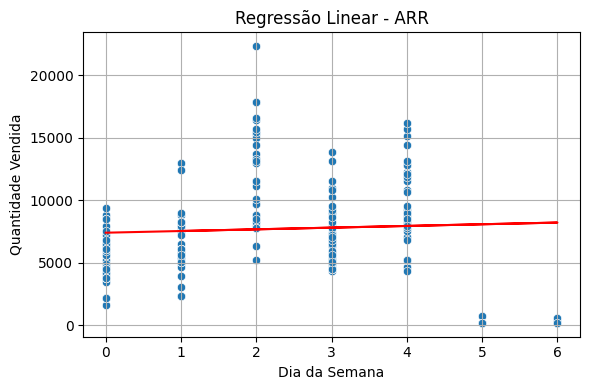

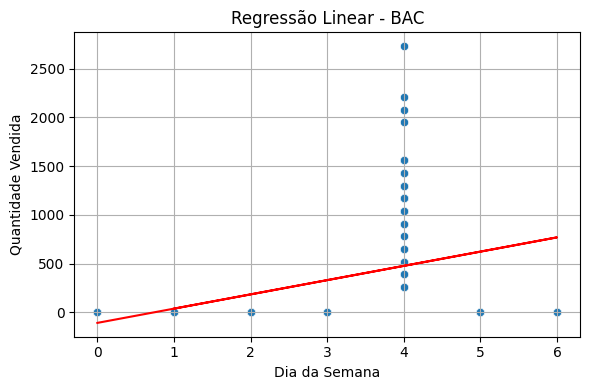

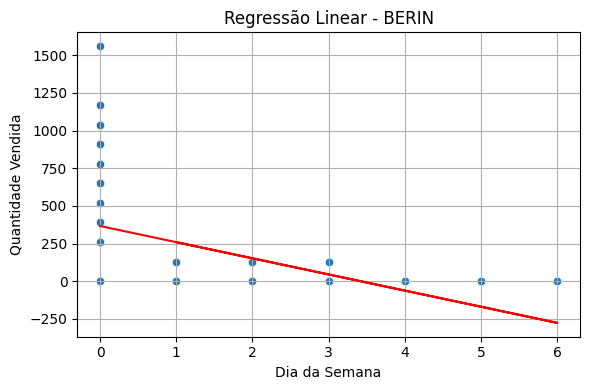

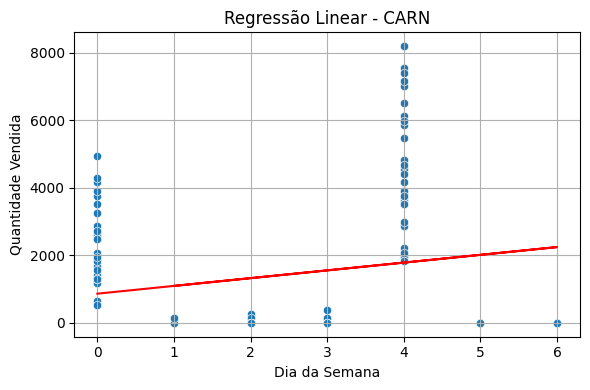

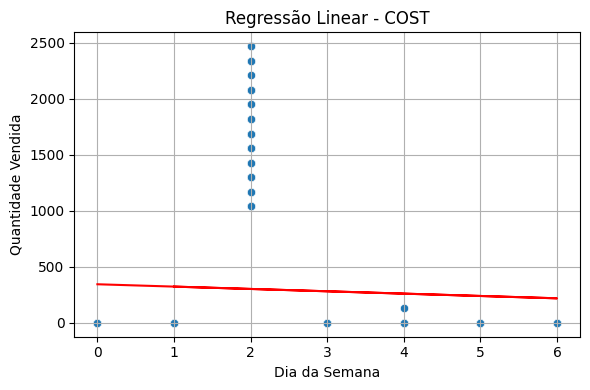

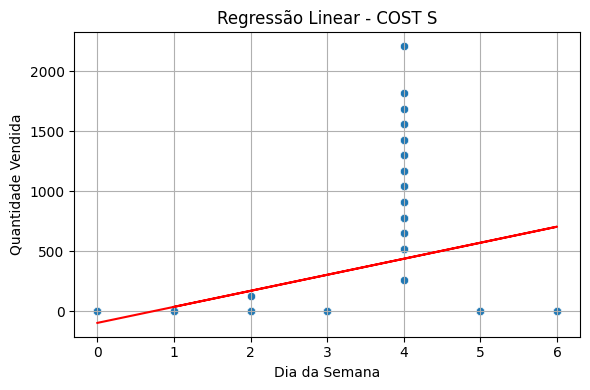

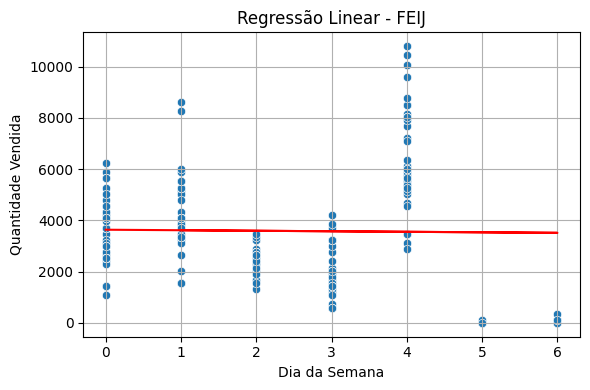

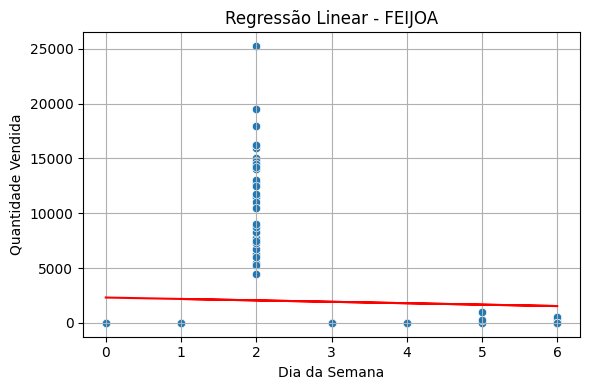

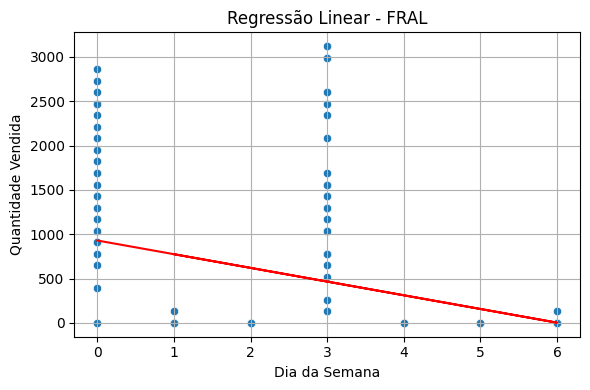

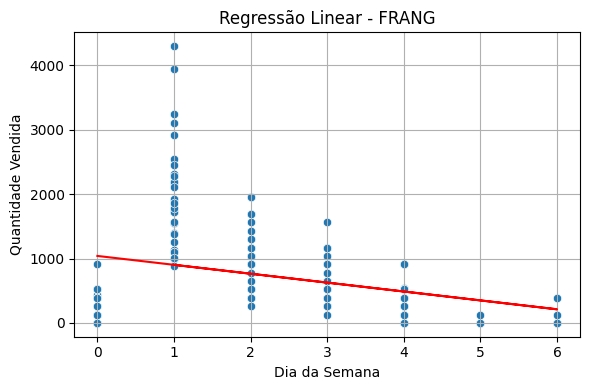

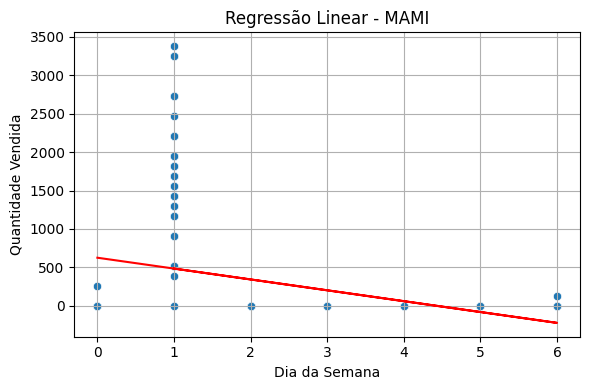

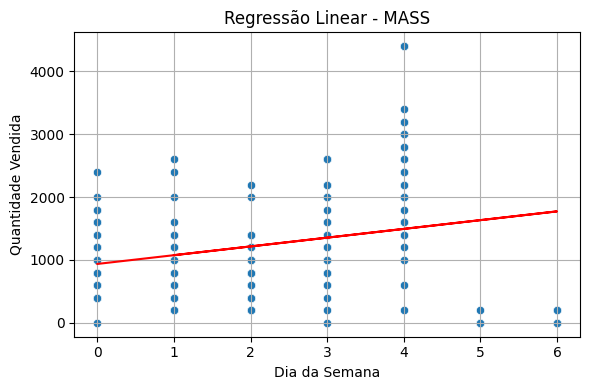

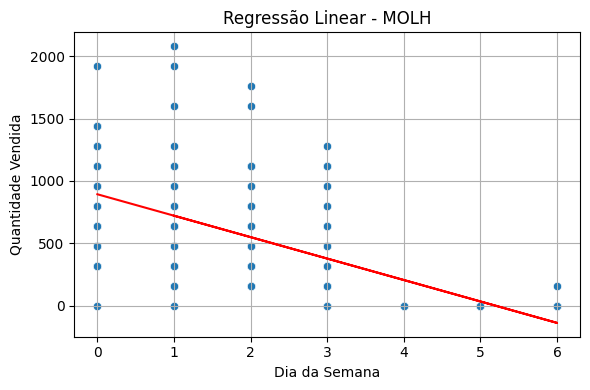

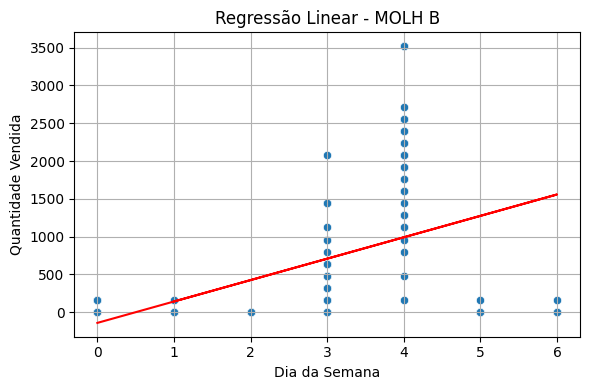

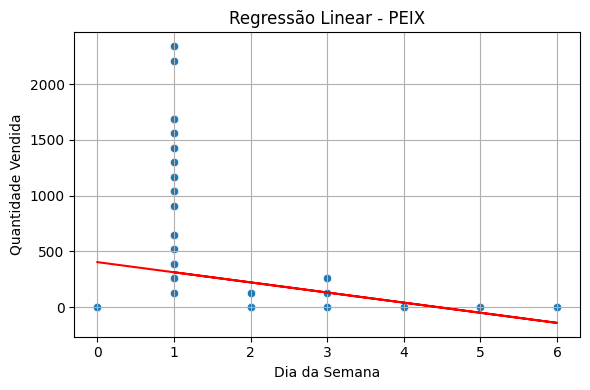

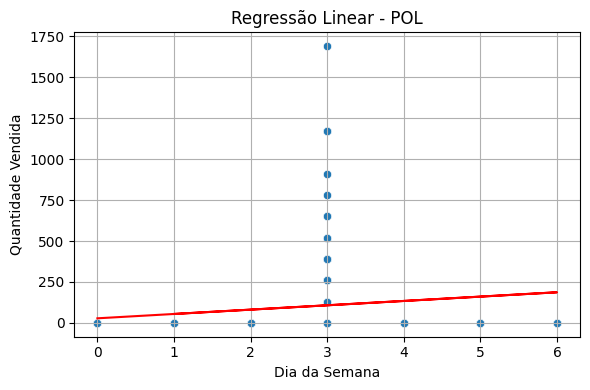

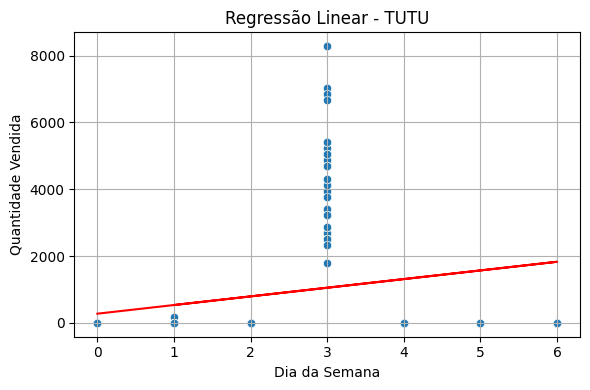

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
import numpy as np

insumos = df.columns[1:-1]  # ignora 'Data' e 'Dia_Semana'

for insumo in insumos:
    X = df[['Dia_Semana']]
    y = df[insumo]

    model = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)

    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=X['Dia_Semana'], y=y)
    plt.plot(X, y_pred, color='red')
    plt.title(f'Regressão Linear - {insumo}')
    plt.xlabel('Dia da Semana')
    plt.ylabel('Quantidade Vendida')
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import pandas as pd

# Garante que a coluna de data está no formato certo
df['Data'] = pd.to_datetime(df['Data'])
df['Dia_Semana'] = df['Data'].dt.dayofweek  # 0 = segunda-feira, 6 = domingo

# Lista de insumos (ignorando 'Data' e 'Dia_Semana')
insumos = [col for col in df.columns if col not in ['Data', 'Dia_Semana']]

# Dicionário para guardar os R²
r2_dict = {}

for insumo in insumos:
    X = df[['Dia_Semana']]
    y = df[insumo]
    
    # Ignora insumos com só zeros
    if y.sum() == 0:
        continue
    
    model = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)
    
    r2 = r2_score(y, y_pred)
    r2_dict[insumo] = r2

# Cria DataFrame dos resultados e ordena
r2_df = pd.DataFrame(list(r2_dict.items()), columns=['Insumo', 'R2_Score'])
r2_df = r2_df.sort_values(by='R2_Score', ascending=False)

print(r2_df)


    Insumo  R2_Score
12    MOLH  0.350861
2    BERIN  0.335910
13  MOLH B  0.304214
5   COST S  0.239275
1      BAC  0.225423
10    MAMI  0.095379
14    PEIX  0.090961
8     FRAL  0.083449
9    FRANG  0.076062
11    MASS  0.062015
16    TUTU  0.051454
3     CARN  0.032364
15     POL  0.031816
0      ARR  0.003022
4     COST  0.002603
7   FEIJOA  0.001940
6     FEIJ  0.000220



Top 3 melhores ajustes:
    Insumo  R2_Score
12    MOLH  0.350861
2    BERIN  0.335910
13  MOLH B  0.304214

Top 3 piores ajustes:
   Insumo  R2_Score
4    COST  0.002603
7  FEIJOA  0.001940
6    FEIJ  0.000220

📊 Gráficos dos 3 melhores ajustes:


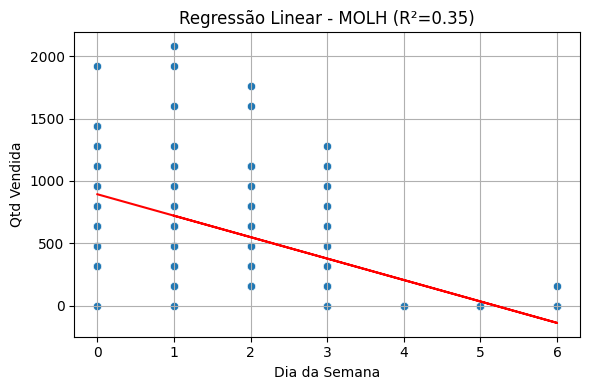

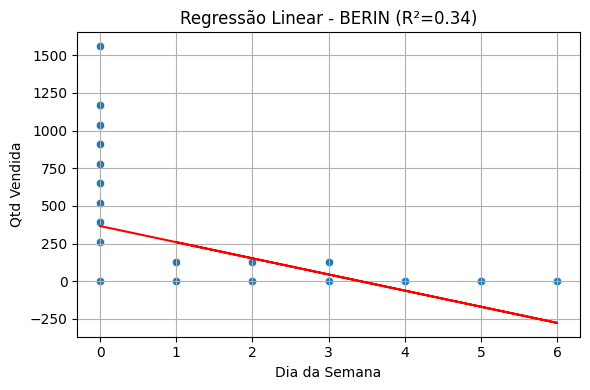

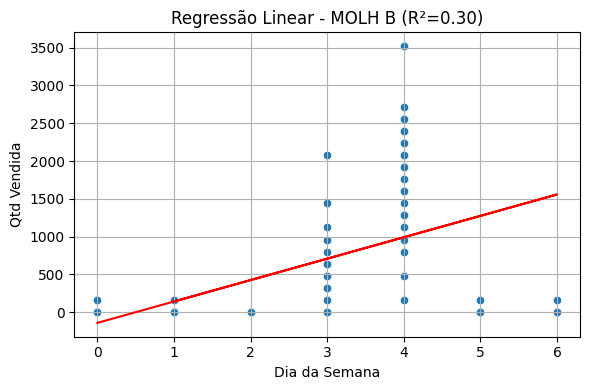


📉 Gráficos dos 3 piores ajustes:


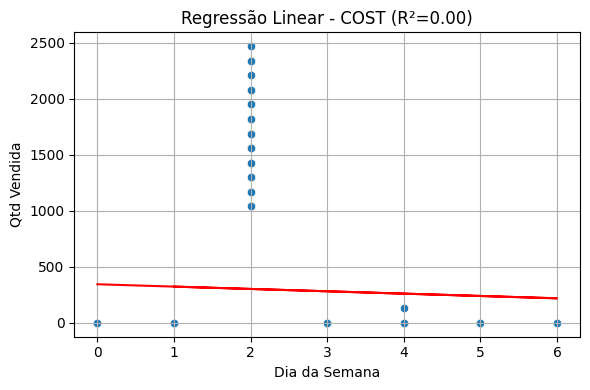

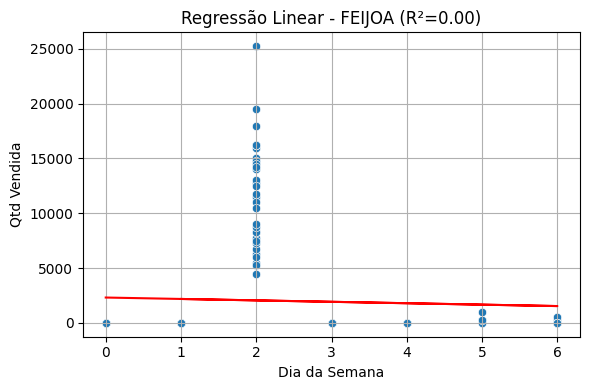

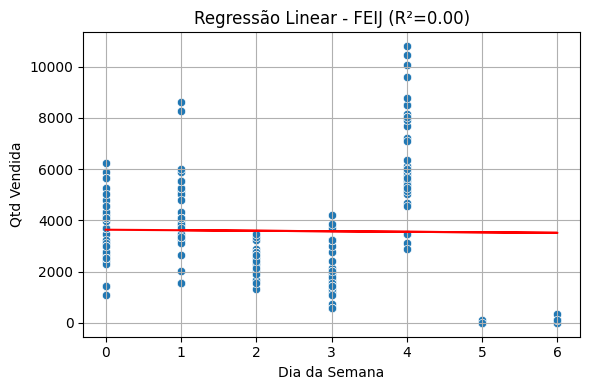

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import seaborn as sns

# Garante formato de data e cria coluna com dia da semana
df['Data'] = pd.to_datetime(df['Data'])
df['Dia_Semana'] = df['Data'].dt.dayofweek  # 0 = segunda-feira

# Lista de insumos (ignora colunas de data e dia da semana)
insumos = [col for col in df.columns if col not in ['Data', 'Dia_Semana']]

r2_dict = {}

# Calcula R² de cada insumo
for insumo in insumos:
    X = df[['Dia_Semana']]
    y = df[insumo]
    
    if y.sum() == 0:
        continue

    model = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)

    r2 = r2_score(y, y_pred)
    r2_dict[insumo] = (r2, y, y_pred)

# Cria DataFrame ordenado por R²
r2_df = pd.DataFrame([(insumo, v[0]) for insumo, v in r2_dict.items()],
                     columns=['Insumo', 'R2_Score']).sort_values(by='R2_Score', ascending=False)

print("\nTop 3 melhores ajustes:")
print(r2_df.head(3))
print("\nTop 3 piores ajustes:")
print(r2_df.tail(3))

# Plot dos 3 melhores e 3 piores
top_3 = r2_df.head(3)['Insumo']
bottom_3 = r2_df.tail(3)['Insumo']

def plot_regression(insumo):
    X = df[['Dia_Semana']]
    y = r2_dict[insumo][1]
    y_pred = r2_dict[insumo][2]

    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=X['Dia_Semana'], y=y)
    plt.plot(X, y_pred, color='red')
    plt.title(f'Regressão Linear - {insumo} (R²={r2_dict[insumo][0]:.2f})')
    plt.xlabel('Dia da Semana')
    plt.ylabel('Qtd Vendida')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Plota todos
print("\n📊 Gráficos dos 3 melhores ajustes:")
for insumo in top_3:
    plot_regression(insumo)

print("\n📉 Gráficos dos 3 piores ajustes:")
for insumo in bottom_3:
    plot_regression(insumo)


Esse código vai te mostrar quais insumos estão mais ou menos previsíveis ao longo dos dias da semana — o que é essencial para tomada de decisão no restaurante.

In [6]:
import pandas as pd
import datetime

# Carrega os dados
df = pd.read_excel("insumos_vendidos_por_dia.xlsx")

# Formata data e extrai dia da semana
df['Data'] = pd.to_datetime(df['Data'])
df['Dia_Semana'] = df['Data'].dt.dayofweek  # 0 = segunda, 6 = domingo

# Calcula média de cada insumo por dia da semana
media_semanal = df.groupby('Dia_Semana').mean(numeric_only=True)

# Gera lista com os próximos 7 dias
hoje = datetime.date.today()
prox_semana = [hoje + datetime.timedelta(days=i) for i in range(1, 8)]
dias_semana = [d.weekday() for d in prox_semana]

# Gera previsão de consumo com base na média de cada dia da semana
previsao = pd.DataFrame([media_semanal.loc[d] for d in dias_semana])
previsao['Data'] = prox_semana
previsao = previsao[['Data'] + [col for col in previsao.columns if col != 'Data']]
previsao.reset_index(drop=True, inplace=True)

# Mostra previsão por dia
print("📅 Previsão de insumos por dia da próxima semana:")
print(previsao)

# Soma total da semana por insumo (previsão mínima de compra)
compra_minima = previsao.drop(columns='Data').sum().round()
print("\n🛒 Previsão mínima total de compra para a semana:")
print(compra_minima)


📅 Previsão de insumos por dia da próxima semana:
         Data           ARR          BAC       BERIN         CARN  \
0  2025-05-05   5480.000000     0.000000  642.777778  2325.555556   
1  2025-05-06   6452.727273     0.000000    3.939394     7.878788   
2  2025-05-07  11925.000000     0.000000    8.125000    12.187500   
3  2025-05-08   7333.714286     0.000000    3.714286    18.571429   
4  2025-05-09   9794.117647  1124.117647    0.000000  4741.176471   
5  2025-05-10    315.000000     0.000000    0.000000     0.000000   
6  2025-05-11    270.000000     0.000000    0.000000     0.000000   

          COST       COST S         FEIJ    FEIJOA         FRAL        FRANG  \
0     0.000000     0.000000  3653.333333      0.00  1476.944444   149.166667   
1     0.000000     0.000000  4298.181818      0.00     3.939394  2006.060606   
2  1677.812500     4.062500  2505.000000  11343.75     0.000000  1015.625000   
3     0.000000     0.000000  2005.714286      0.00  1511.714286   631.428571  

In [7]:
import pandas as pd
import datetime

# Carrega os dados
df = pd.read_excel("insumos_vendidos_por_dia.xlsx")

# Formata data e extrai dia da semana
df['Data'] = pd.to_datetime(df['Data'])
df['Dia_Semana'] = df['Data'].dt.dayofweek  # 0 = segunda, 6 = domingo

# Calcula média de cada insumo por dia da semana
media_semanal = df.groupby('Dia_Semana').mean(numeric_only=True)

# Gera lista com os próximos 7 dias
hoje = datetime.date.today()
prox_semana = [hoje + datetime.timedelta(days=i) for i in range(1, 8)]
dias_semana = [d.weekday() for d in prox_semana]

# Gera previsão de consumo com base na média de cada dia da semana
previsao = pd.DataFrame([media_semanal.loc[d] for d in dias_semana])
previsao['Data'] = prox_semana
previsao = previsao[['Data'] + [col for col in previsao.columns if col != 'Data']]
previsao.reset_index(drop=True, inplace=True)

# DataFrame com previsão total da semana (quantidade mínima a comprar por insumo)
compra_minima = previsao.drop(columns='Data').sum().round()
compra_minima_df = compra_minima.reset_index()
compra_minima_df.columns = ['Insumo', 'Quantidade_Minima']

# Resultado final
previsao_df = previsao.copy()  # previsão por dia
compra_minima_df  # previsão mínima total


,Insumo,Quantidade_Minima
0,ARR,41571.0
1,BAC,1124.0
2,BERIN,659.0
3,CARN,7105.0
4,COST,1682.0
5,COST S,1033.0
6,FEIJ,19142.0
7,FEIJOA,11844.0
8,FRAL,3014.0
9,FRANG,4098.0


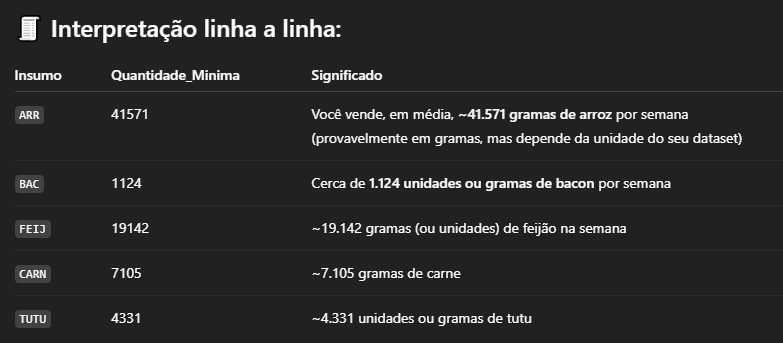